# Bismillah
# Regression Assignment - California Housing Dataset
**Student:** Murtaza Ali  
**Dataset:** housing.csv (California Housing)  
**Target:** `median_house_value` predict karna

## Step 1: Libraries Import

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

print('Libraries import ho gayi!')

Libraries import ho gayi!


## Step 2: Dataset Load aur Basic Analysis

In [2]:
# Dataset load karo
df = pd.read_csv('housing.csv')

print('Dataset Shape:', df.shape)
print('\nPehli 5 rows:')
df.head()

Dataset Shape: (20640, 10)

Pehli 5 rows:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [3]:
# Dataset ka overview
print('Columns:', df.columns.tolist())
print('\nData types:')
print(df.dtypes)
print('\nBasic Statistics:')
df.describe()

Columns: ['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity']

Data types:
longitude             float64
latitude              float64
housing_median_age    float64
total_rooms           float64
total_bedrooms        float64
population            float64
households            float64
median_income         float64
median_house_value    float64
ocean_proximity        object
dtype: object

Basic Statistics:


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [4]:
# Missing values check karo
print('Missing Values:')
print(df.isnull().sum())

Missing Values:
longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64


## Step 3: Missing Values Handle karna
- `total_bedrooms` mein 207 missing values hain
- Hum median se fill karenge (median zyada robust hota hai outliers ke liye)

In [5]:
# total_bedrooms ki missing values median se fill karo
df['total_bedrooms'].fillna(df['total_bedrooms'].median(), inplace=True)

# Verify karo
print('Missing values ab:')
print(df.isnull().sum())
print('\nSab theek hai!')

Missing values ab:
longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

Sab theek hai!


## Step 4: Encoding - Categorical Column ko Numerical banao
- `ocean_proximity` ek categorical (text) column hai
- Hum `pd.get_dummies()` use karenge ise numbers mein convert karne ke liye

In [6]:
# ocean_proximity column ke unique values dekho
print('ocean_proximity ke unique values:')
print(df['ocean_proximity'].value_counts())

ocean_proximity ke unique values:
ocean_proximity
<1H OCEAN     9136
INLAND        6551
NEAR OCEAN    2658
NEAR BAY      2290
ISLAND           5
Name: count, dtype: int64


In [7]:
# One-Hot Encoding apply karo
df = pd.get_dummies(df, columns=['ocean_proximity'], dtype=int)

print('Encoding ke baad columns:')
print(df.columns.tolist())
df.head()

Encoding ke baad columns:
['longitude', 'latitude', 'housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value', 'ocean_proximity_<1H OCEAN', 'ocean_proximity_INLAND', 'ocean_proximity_ISLAND', 'ocean_proximity_NEAR BAY', 'ocean_proximity_NEAR OCEAN']


,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity_<1H OCEAN,ocean_proximity_INLAND,ocean_proximity_ISLAND,ocean_proximity_NEAR BAY,ocean_proximity_NEAR OCEAN
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,0,0,0,1,0
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,0,0,0,1,0
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,0,0,0,1,0
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,0,0,0,1,0
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,0,0,0,1,0


## Step 5: Feature Scaling
- Regression models mein features ko same scale pe laana zaroori hai
- `StandardScaler` use karenge (mean=0, std=1 bana deta hai)
- **Note:** Scaling sirf X pe hogi, y (target) pe nahi

In [8]:
# Features (X) aur Target (y) alag karo
X = df.drop(columns=['median_house_value'])  # Features
y = df['median_house_value']                  # Target

print('Features shape:', X.shape)
print('Target shape:', y.shape)

Features shape: (20640, 13)
Target shape: (20640,)


In [9]:
# Train-Test Split (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print('Training set size:', X_train.shape)
print('Testing set size:', X_test.shape)

Training set size: (16512, 13)
Testing set size: (4128, 13)


In [10]:
# StandardScaler apply karo
scaler = StandardScaler()

# Sirf train data pe fit karo, phir dono pe transform karo
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print('Scaling ho gayi!')
print('X_train_scaled shape:', X_train_scaled.shape)

Scaling ho gayi!
X_train_scaled shape: (16512, 13)


## Step 6: Regression Models Train karna

Hum 3 models try karenge:
1. **Linear Regression** - sabse simple model
2. **Decision Tree Regressor** - rule-based model
3. **Random Forest Regressor** - ensemble model (sabse zyada powerful)

In [11]:
# Helper function - ek baar mein saari metrics calculate karo
def evaluate_model(name, y_test, y_pred):
    mae  = mean_absolute_error(y_test, y_pred)
    mse  = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2   = r2_score(y_test, y_pred)
    print(f'--- {name} ---')
    print(f'MAE  : {mae:,.2f}')
    print(f'MSE  : {mse:,.2f}')
    print(f'RMSE : {rmse:,.2f}')
    print(f'R²   : {r2:.4f}')
    print()
    return {'Model': name, 'MAE': mae, 'MSE': mse, 'RMSE': rmse, 'R2': r2}

In [12]:
# Model 1: Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

result_lr = evaluate_model('Linear Regression', y_test, y_pred_lr)

--- Linear Regression ---
MAE  : 50,670.74
MSE  : 4,908,476,721.16
RMSE : 70,060.52
R²   : 0.6254



In [13]:
# Model 2: Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train_scaled, y_train)
y_pred_dt = dt.predict(X_test_scaled)

result_dt = evaluate_model('Decision Tree', y_test, y_pred_dt)

--- Decision Tree ---
MAE  : 43,550.40
MSE  : 4,771,875,804.93
RMSE : 69,078.77
R²   : 0.6358



In [14]:
# Model 3: Random Forest Regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

result_rf = evaluate_model('Random Forest', y_test, y_pred_rf)

--- Random Forest ---
MAE  : 31,628.59
MSE  : 2,395,314,930.14
RMSE : 48,941.95
R²   : 0.8172



## Step 7: Models ki Performance Compare karna

In [15]:
# Saari results ek table mein dekho
results_df = pd.DataFrame([result_lr, result_dt, result_rf])
results_df = results_df.set_index('Model')
print('Models ka Comparison:')
results_df

Models ka Comparison:


,MAE,MSE,RMSE,R2
Model,,,,
Linear Regression,50670.738241,4.908477e+09,70060.521845,0.625424
Decision Tree,43550.404797,4.771876e+09,69078.765224,0.635848
Random Forest,31628.592391,2.395315e+09,48941.954703,0.817209


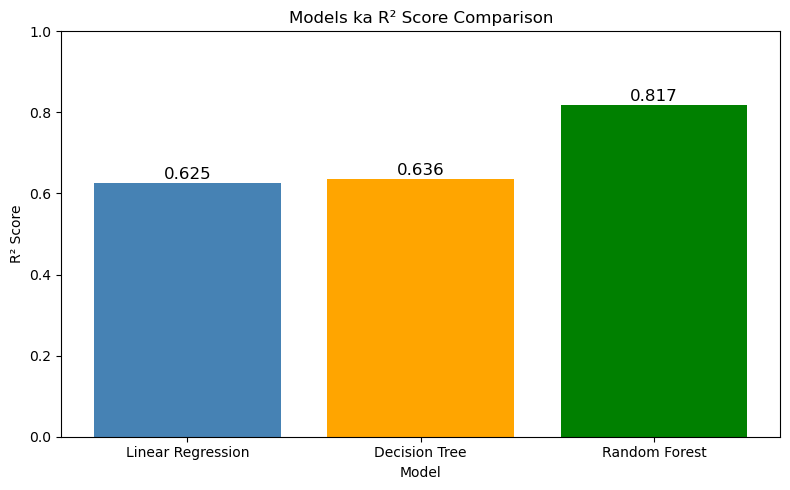

In [16]:
# R2 Score ka bar chart
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df['R2'], color=['steelblue', 'orange', 'green'])
plt.title('Models ka R² Score Comparison')
plt.xlabel('Model')
plt.ylabel('R² Score')
plt.ylim(0, 1)
for i, v in enumerate(results_df['R2']):
    plt.text(i, v + 0.01, f'{v:.3f}', ha='center', fontsize=12)
plt.tight_layout()
plt.show()

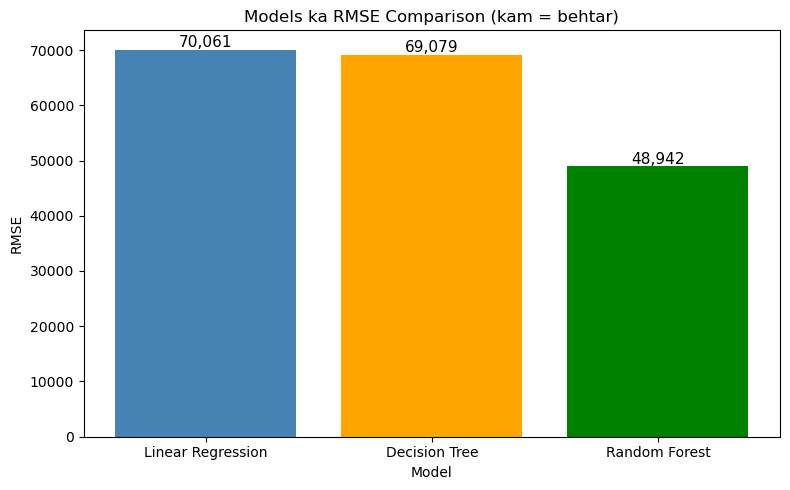

In [17]:
# RMSE ka bar chart
plt.figure(figsize=(8, 5))
plt.bar(results_df.index, results_df['RMSE'], color=['steelblue', 'orange', 'green'])
plt.title('Models ka RMSE Comparison (kam = behtar)')
plt.xlabel('Model')
plt.ylabel('RMSE')
for i, v in enumerate(results_df['RMSE']):
    plt.text(i, v + 500, f'{v:,.0f}', ha='center', fontsize=11)
plt.tight_layout()
plt.show()

## Step 8: Plotting - Actual vs Predicted Values

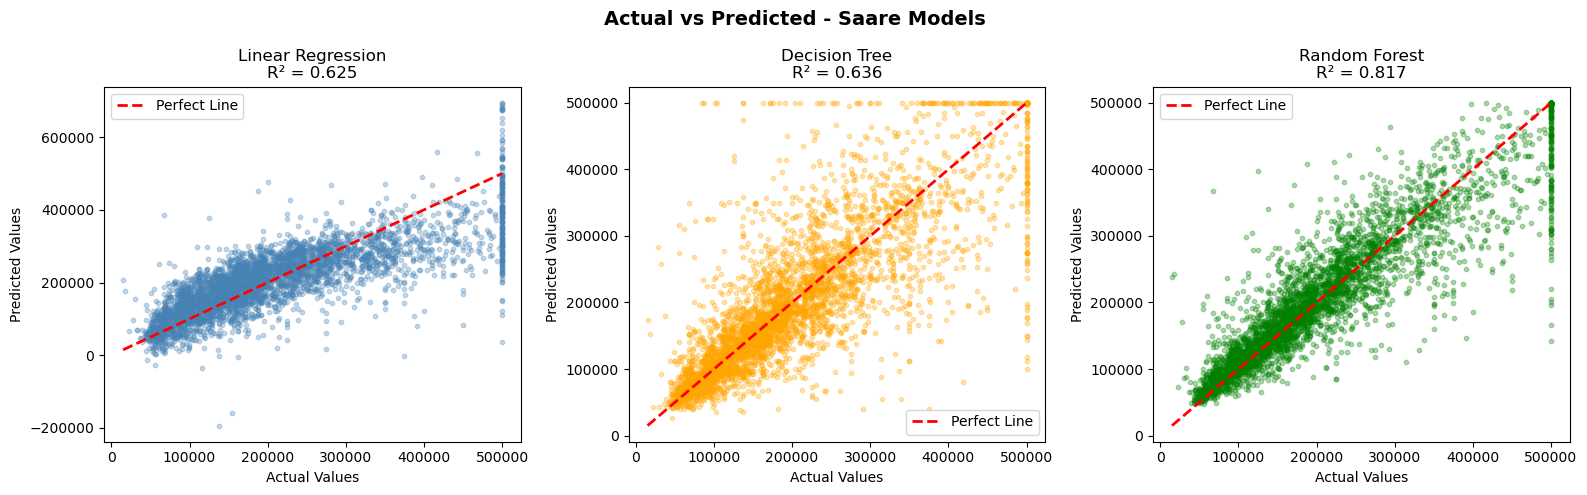

In [18]:
# Teenon models ke liye Actual vs Predicted plot
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

models_preds = [
    ('Linear Regression', y_pred_lr),
    ('Decision Tree',     y_pred_dt),
    ('Random Forest',     y_pred_rf)
]

colors = ['steelblue', 'orange', 'green']

for ax, (name, preds), color in zip(axes, models_preds, colors):
    ax.scatter(y_test, preds, alpha=0.3, color=color, s=10)
    ax.plot([y_test.min(), y_test.max()],
            [y_test.min(), y_test.max()],
            'r--', lw=2, label='Perfect Line')
    ax.set_title(f'{name}\nR² = {r2_score(y_test, preds):.3f}')
    ax.set_xlabel('Actual Values')
    ax.set_ylabel('Predicted Values')
    ax.legend()

plt.suptitle('Actual vs Predicted - Saare Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 9: Feature Importance (Random Forest)
- Random Forest batata hai konsa feature zyada important hai

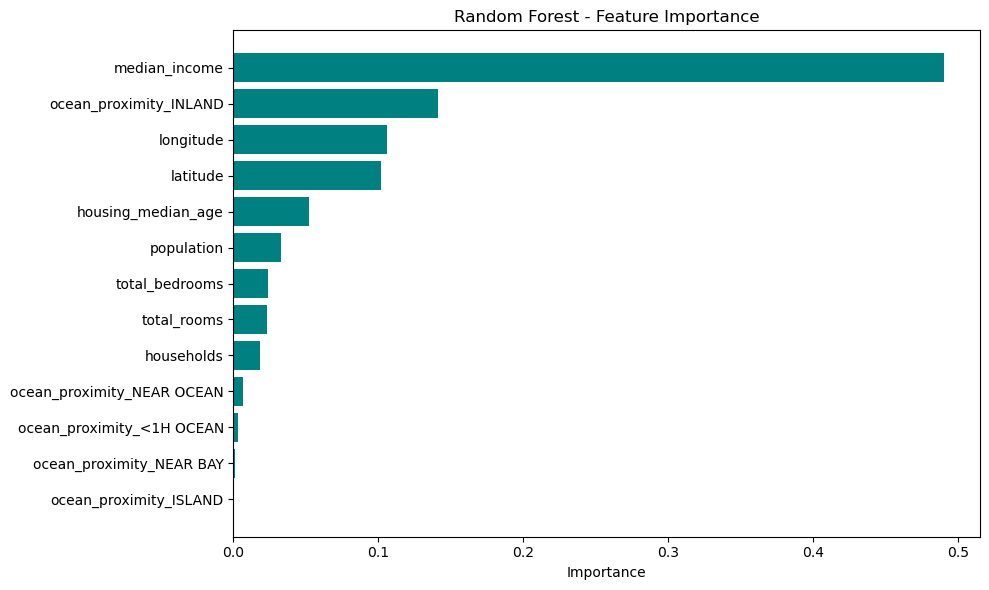

                   Feature  Importance
             median_income    0.490642
    ocean_proximity_INLAND    0.140925
                 longitude    0.105889
                  latitude    0.101597
        housing_median_age    0.051935
                population    0.032573
            total_bedrooms    0.023819
               total_rooms    0.023366
                households    0.018367
ocean_proximity_NEAR OCEAN    0.006336
 ocean_proximity_<1H OCEAN    0.003386
  ocean_proximity_NEAR BAY    0.000711
    ocean_proximity_ISLAND    0.000455


In [19]:
# Feature Importance nikalo
feature_names = X.columns.tolist()
importances = rf.feature_importances_

fi_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
fi_df = fi_df.sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(fi_df['Feature'], fi_df['Importance'], color='teal')
plt.title('Random Forest - Feature Importance')
plt.xlabel('Importance')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print(fi_df.to_string(index=False))

## Step 10: Hyperparameter Tuning - Random Forest ko aur improve karo
- `GridSearchCV` se best parameters dhundhenge
- **Note:** Time bachane ke liye chhota grid use kar rahe hain

In [20]:
# Hyperparameter grid define karo
param_grid = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

# GridSearchCV run karo (cv=3 matlab 3-fold cross validation)
print('GridSearchCV chal rahi hai... thoda wait karo...')

grid_search = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_scaled, y_train)

print('\nBest Parameters:')
print(grid_search.best_params_)
print(f'\nBest CV R² Score: {grid_search.best_score_:.4f}')

GridSearchCV chal rahi hai... thoda wait karo...
Fitting 3 folds for each of 12 candidates, totalling 36 fits



Best Parameters:
{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}

Best CV R² Score: 0.8133


In [21]:
# Best model se predict karo
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

result_best = evaluate_model('Tuned Random Forest', y_test, y_pred_best)

# Before aur After compare karo
print(f'Before Tuning - R²: {result_rf["R2"]:.4f}')
print(f'After  Tuning - R²: {result_best["R2"]:.4f}')

--- Tuned Random Forest ---
MAE  : 31,464.93
MSE  : 2,379,640,474.73
RMSE : 48,781.56
R²   : 0.8184

Before Tuning - R²: 0.8172
After  Tuning - R²: 0.8184


## Step 11: Final Model Selection aur Summary

In [22]:
# Saare results final comparison
all_results = pd.DataFrame([result_lr, result_dt, result_rf, result_best])
all_results = all_results.set_index('Model')

print('=== Final Model Comparison ===')
print(all_results.to_string())

# Best model choose karo (R² zyada = behtar)
best_model_name = all_results['R2'].idxmax()
best_r2 = all_results['R2'].max()
print(f'\n✅ Best Model: {best_model_name}')
print(f'   R² Score: {best_r2:.4f}')

=== Final Model Comparison ===
                              MAE           MSE          RMSE        R2
Model                                                                  
Linear Regression    50670.738241  4.908477e+09  70060.521845  0.625424
Decision Tree        43550.404797  4.771876e+09  69078.765224  0.635848
Random Forest        31628.592391  2.395315e+09  48941.954703  0.817209
Tuned Random Forest  31464.933474  2.379640e+09  48781.558757  0.818405

✅ Best Model: Tuned Random Forest
   R² Score: 0.8184


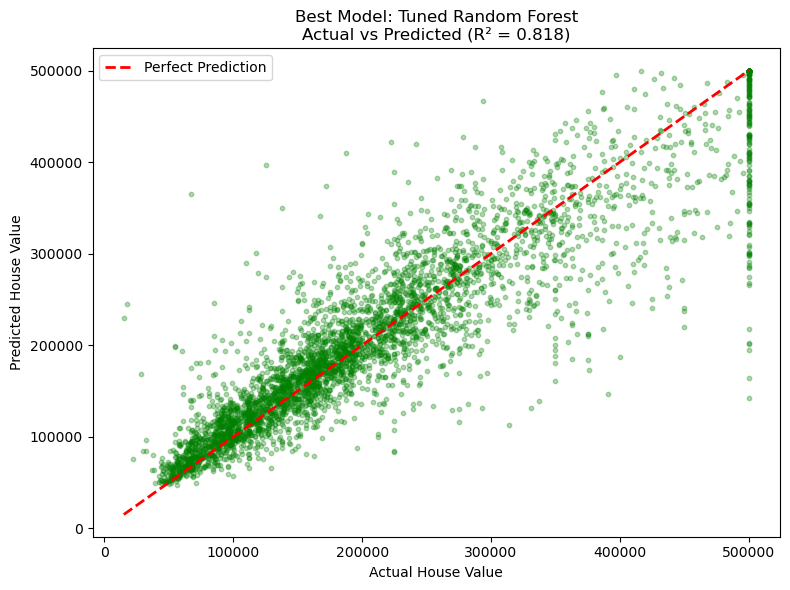

In [23]:
# Final Actual vs Predicted plot - Best Model ka
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_best, alpha=0.3, color='green', s=10)
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         'r--', lw=2, label='Perfect Prediction')
plt.title(f'Best Model: Tuned Random Forest\nActual vs Predicted (R² = {result_best["R2"]:.3f})')
plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.legend()
plt.tight_layout()
plt.show()

## Conclusion

Is assignment mein humne California Housing dataset pe regression kiya:

| Step | Kya kiya |
|------|----------|
| Data Analysis | Shape, dtypes, statistics dekhe |
| Missing Values | `total_bedrooms` ki 207 missing values median se fill ki |
| Encoding | `ocean_proximity` (text) ko One-Hot Encoding se numbers mein badla |
| Feature Scaling | StandardScaler se sab features same scale pe laye |
| Models | Linear Regression, Decision Tree, Random Forest train kiye |
| Metrics | MAE, MSE, RMSE, R² calculate kiye |
| Tuning | GridSearchCV se Random Forest ke best parameters dhundhe |

**Best Model: Tuned Random Forest** — kyunki is ka R² score sabse zyada hai.

**Sabse important feature:** `median_income` — ghar ki keemat mein income ka sabse zyada role hota hai.